# 04 · Multilooking, Fading Speckle & Forward Model Validation

Reproduces **Fig. 6** of De Zan et al. (2014): modelled (dashed) vs observed
(solid) coherence magnitudes for the AGRISAR 2006 dataset, HH+VV polarisation,
field 222. Each sub-panel uses a different master image.

Also shows how multilook window size affects coherence estimation variance
(fading speckle).

> **Note — Fig. 7 of De Zan (2014)** is a real E-SAR L-band interferogram over
> the AGRISAR test site near Demmin, Germany (May-24 / Jun-06 pair). It requires
> the original ESA airborne dataset and cannot be reproduced here. The key
> observable it shows — phase discontinuities at agricultural field boundaries —
> is a direct consequence of the moisture-dependent phase predicted by Eq. (14),
> which is what this notebook validates.

---
**References**
- De Zan, F., Parizzi, A., Prats-Iraola, P., & López-Dekker, P. (2014).
  *A SAR interferometric model for soil moisture.*
  IEEE Transactions on Geoscience and Remote Sensing, 52(1), 418–425.
  https://doi.org/10.1109/TGRS.2013.2241069

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from navasar.coherence import interferometric_coherence
from navasar.slc import simulate_slc, multilook_interferogram

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
COH_KW = dict(freq_ghz=1.4, theta_inc_deg=45.0, sand=0.51, clay=0.13)
SLC_KW = dict(freq_ghz=1.4, sand=0.51, clay=0.13)

## AGRISAR 2006 moisture time-series (field 101, in-situ)

Approximate values digitised from Fig. 12 of De Zan (2014).

In [2]:
doy    = np.array([131, 144, 157, 164, 172, 186, 193, 203])
labels = ['May-11','May-24','Jun-06','Jun-13','Jun-21','Jul-05','Jul-12','Aug-02']
mv_obs = np.array([0.28, 0.22, 0.18, 0.15, 0.12, 0.10, 0.09, 0.08])
n = len(mv_obs)

# Build the SLC stack ONCE so all master/slave pairs share the same
# scatterer realisation — coherence estimates are then consistent
rng = np.random.default_rng(0)
slc_stack = simulate_slc(mv_obs, n_pixels=400, n_layers=100,
                          max_depth=0.30, rng=rng, **SLC_KW)
print(f'SLC stack: {slc_stack.shape}  (acquisitions × pixels)')

SLC stack: (8, 400)  (acquisitions × pixels)


## Fig. 6 — Modelled vs observed coherences (De Zan 2014)

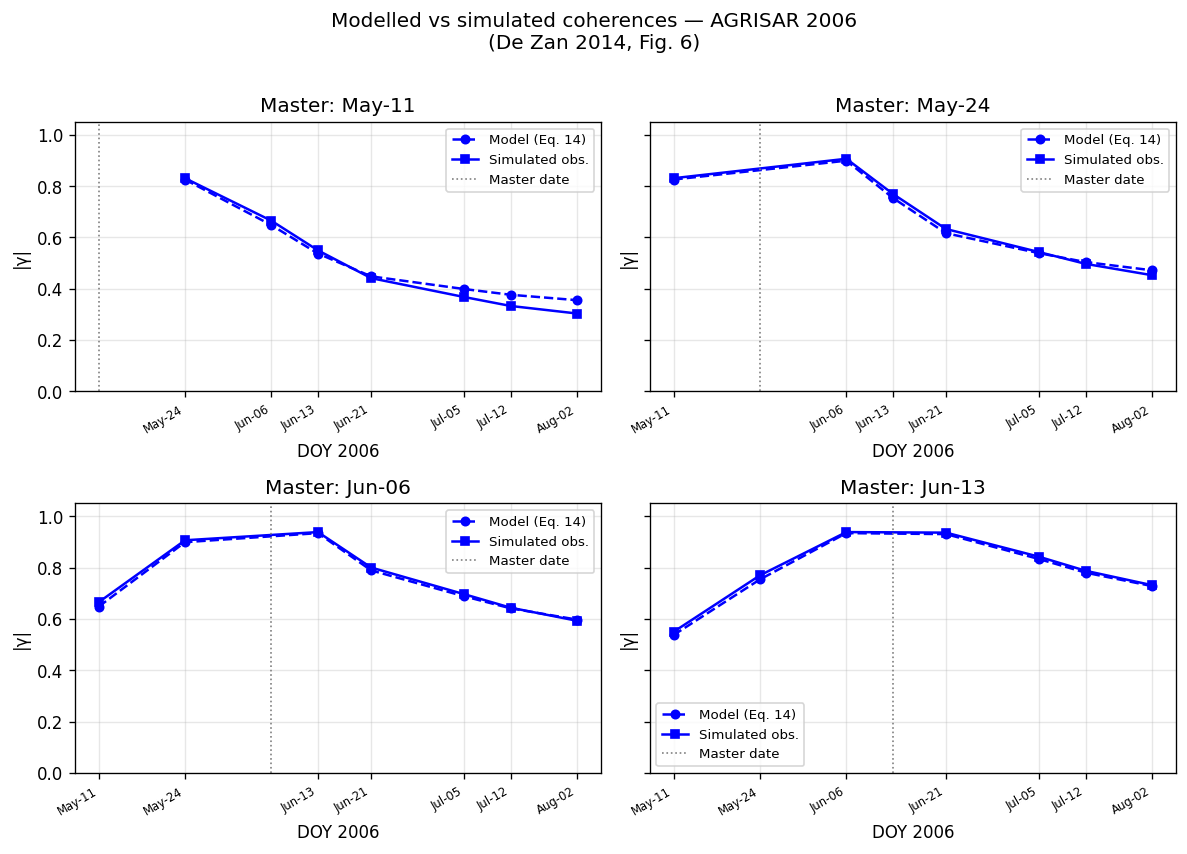

In [3]:
n_masters = 4
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for mi, master_idx in enumerate(range(n_masters)):
    ax = axes[mi]
    slave_idx = [s for s in range(n) if s != master_idx]
    slave_doy = doy[slave_idx]

    # Modelled coherence — De Zan 2014, Eq. (14)
    coh_model = np.abs(interferometric_coherence(
        mv_obs[master_idx], mv_obs[slave_idx], **COH_KW))

    # Simulated "observed" coherence from the pre-built SLC stack
    z_mm = multilook_interferogram(slc_stack[master_idx], slc_stack[master_idx])
    coh_sim = np.array([
        abs(multilook_interferogram(slc_stack[master_idx], slc_stack[s]))
        / np.sqrt(abs(z_mm) * abs(multilook_interferogram(slc_stack[s], slc_stack[s])))
        for s in slave_idx
    ])

    ax.plot(slave_doy, coh_model, 'b--o', ms=5, label='Model (Eq. 14)')
    ax.plot(slave_doy, coh_sim,   'b-s',  ms=5, label='Simulated obs.')
    ax.axvline(doy[master_idx], color='gray', ls=':', lw=1, label='Master date')
    ax.set_title(f'Master: {labels[master_idx]}')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('DOY 2006')
    ax.set_ylabel('|γ|')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(slave_doy)
    ax.set_xticklabels([labels[s] for s in slave_idx],
                       rotation=30, ha='right', fontsize=7)

plt.suptitle('Modelled vs simulated coherences — AGRISAR 2006\n(De Zan 2014, Fig. 6)', y=1.01)
plt.tight_layout()
plt.savefig('../examples/fig06_coherence_validation.png', dpi=150)
plt.show()

## Effect of multilook window size on coherence estimation (fading speckle)

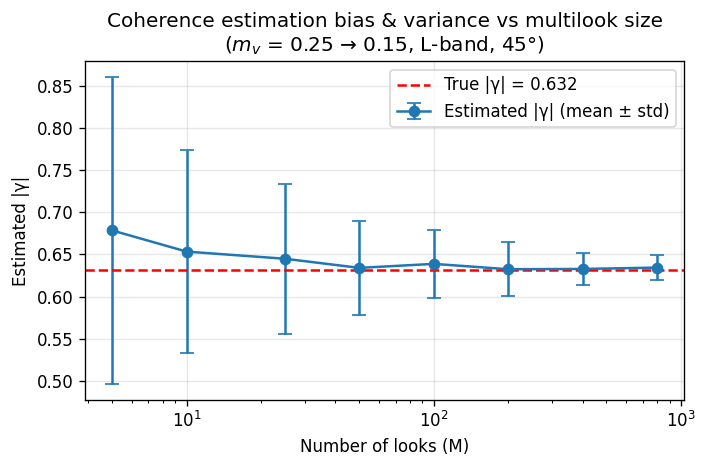

In [4]:
mv_pair  = np.array([0.25, 0.15])
true_coh = abs(interferometric_coherence(mv_pair[0], mv_pair[1], **COH_KW))

n_looks_range = [5, 10, 25, 50, 100, 200, 400, 800]
n_trials = 100
mean_coh, std_coh = [], []

for nl in n_looks_range:
    estimates = []
    for _ in range(n_trials):
        slc = simulate_slc(mv_pair, n_pixels=nl, n_layers=100,
                           max_depth=0.30, rng=np.random.default_rng(), **SLC_KW)
        z12 = multilook_interferogram(slc[0], slc[1])
        z11 = multilook_interferogram(slc[0], slc[0])
        z22 = multilook_interferogram(slc[1], slc[1])
        estimates.append(abs(z12) / np.sqrt(abs(z11) * abs(z22)))
    mean_coh.append(np.mean(estimates))
    std_coh.append(np.std(estimates))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(n_looks_range, mean_coh, yerr=std_coh, fmt='o-', capsize=4,
            label='Estimated |γ| (mean ± std)')
ax.axhline(true_coh, color='r', ls='--', label=f'True |γ| = {true_coh:.3f}')
ax.set_xscale('log')
ax.set_xlabel('Number of looks (M)')
ax.set_ylabel('Estimated |γ|')
ax.set_title('Coherence estimation bias & variance vs multilook size\n'
             '($m_v$ = 0.25 → 0.15, L-band, 45°)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../examples/fig_multilook_fading.png', dpi=150)
plt.show()